### What is Cache-Augmented Generation (CAG)?
CAG is a retrieval-free approach that bypasses the usual step of querying external knowledge sources at inference time. Instead, it preloads relevant documents into the LLM's extended context window, precomputes the model’s key‑value (KV) cache, and reuses this during inference—so the model can generate responses without additional retrieval steps 

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

from langchain.chat_models import init_chat_model
llm=init_chat_model(model="groq:openai/gpt-oss-120b",temperature=0)

llm

c:\D_Drive\RAGUdemy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002E3532CB230>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002E35348C050>, model_name='openai/gpt-oss-120b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [2]:
### Cache variable
Model_Cache={}

In [3]:
import time

def cache_model(query):
    start_time=time.time()
    if Model_Cache.get(query):
        print("**CAche Hit**")
        end_time=time.time()
        elapsed_time=end_time-start_time
        print(f"EXECUTION TIME: {elapsed_time:.2f} seconds")
        return Model_Cache.get(query)
    else:
        print("***CACHE MISS – EXECUTING MODEL***")
        start_time = time.time()
        response = llm.invoke(query)
        end_time = time.time()
        elapsed = end_time - start_time
        print(f"EXECUTION TIME: {elapsed:.2f} seconds")
        Model_Cache[query] = response
        return response


In [4]:
response=cache_model("hi")
response

***CACHE MISS – EXECUTING MODEL***
EXECUTION TIME: 0.38 seconds


AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi". We need to respond appropriately. It\'s a simple greeting. We can respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 72, 'total_tokens': 113, 'completion_time': 0.088176503, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.003152835, 'prompt_tokens_details': None, 'queue_time': 0.050865375, 'total_time': 0.091329338}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_ce855234b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dd97b-87e9-7953-a6f7-ac72c78a0da8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 41, 'total_tokens': 113, 'output_token_details': {'reasoning': 23}})

In [5]:
Model_Cache

{'hi': AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi". We need to respond appropriately. It\'s a simple greeting. We can respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 72, 'total_tokens': 113, 'completion_time': 0.088176503, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.003152835, 'prompt_tokens_details': None, 'queue_time': 0.050865375, 'total_time': 0.091329338}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_ce855234b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dd97b-87e9-7953-a6f7-ac72c78a0da8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 41, 'total_tokens': 113, 'output_token_details': {'reasoning': 23}})}

In [6]:
response=cache_model("hi")
response

**CAche Hit**
EXECUTION TIME: 0.00 seconds


AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi". We need to respond appropriately. It\'s a simple greeting. We can respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 72, 'total_tokens': 113, 'completion_time': 0.088176503, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.003152835, 'prompt_tokens_details': None, 'queue_time': 0.050865375, 'total_time': 0.091329338}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_ce855234b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dd97b-87e9-7953-a6f7-ac72c78a0da8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 41, 'total_tokens': 113, 'output_token_details': {'reasoning': 23}})

In [7]:
query="can you give me 500 words on langgraph?"
response =cache_model(query)
print(response)

***CACHE MISS – EXECUTING MODEL***
EXECUTION TIME: 3.19 seconds
content='**LangGraph: A 500‑Word Overview**\n\nLangGraph is an open‑source Python library that makes it easy to construct, visualize, and execute complex, state‑driven workflows for large‑language‑model (LLM) applications. Built on top of LangChain, LangGraph adds a graph‑oriented abstraction layer that lets developers think of an LLM‑powered system as a network of interconnected “nodes” (tasks) and “edges” (transitions). This paradigm mirrors how humans solve multi‑step problems: we break a challenge into sub‑tasks, decide which result feeds into the next step, and loop back when new information emerges. By formalizing that process, LangGraph helps teams build more reliable, maintainable, and debuggable AI products.\n\n### Core Concepts\n\n1. **Nodes** – A node encapsulates a single unit of work. In practice, a node can be a prompt template sent to an LLM, a call to an external API, a data‑retrieval operation, or any cust

In [8]:
query="give me 500 words on langgraph?"
response =cache_model(query)
print(response)

***CACHE MISS – EXECUTING MODEL***
EXECUTION TIME: 3.61 seconds
content='**LangGraph: A 500‑Word Overview of the Emerging Graph‑Based Framework for LLM Applications**\n\nLangGraph is an open‑source Python library that extends the capabilities of large language models (LLMs) by allowing developers to compose, orchestrate, and debug complex, stateful workflows as directed graphs. Inspired by the success of LangChain—where chains of prompts and tools are linked linearly—LangGraph treats each node as an autonomous “agent” or “tool” and each edge as a transition rule, enabling richer control flow, parallelism, and dynamic branching. The result is a more expressive, maintainable, and observable architecture for building conversational assistants, autonomous agents, data pipelines, and any application that requires multi‑step reasoning.\n\n---\n\n### Core Concepts\n\n1. **Node** – The fundamental unit of computation. A node can be a prompt template, a function call, an external API, or a cust

In [9]:
query="can you give me 500 words on langgraph?"
response =cache_model(query)
print(response)

**CAche Hit**
EXECUTION TIME: 0.00 seconds
content='**LangGraph: A 500‑Word Overview**\n\nLangGraph is an open‑source Python library that makes it easy to construct, visualize, and execute complex, state‑driven workflows for large‑language‑model (LLM) applications. Built on top of LangChain, LangGraph adds a graph‑oriented abstraction layer that lets developers think of an LLM‑powered system as a network of interconnected “nodes” (tasks) and “edges” (transitions). This paradigm mirrors how humans solve multi‑step problems: we break a challenge into sub‑tasks, decide which result feeds into the next step, and loop back when new information emerges. By formalizing that process, LangGraph helps teams build more reliable, maintainable, and debuggable AI products.\n\n### Core Concepts\n\n1. **Nodes** – A node encapsulates a single unit of work. In practice, a node can be a prompt template sent to an LLM, a call to an external API, a data‑retrieval operation, or any custom Python function. N

### Advanced CAG

In [10]:
from __future__ import annotations
from typing import TypedDict, List, Optional
import time

# ---- LangGraph / LangChain ----
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

from langchain_core.documents import Document
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

# ---- FAISS vector stores ----
import faiss
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore

In [11]:
# ================= CONFIG =================
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"  # 384-dim
VECTOR_DIM = 384

LLM_MODEL = "openai/gpt-oss-120b"
LLM_TEMPERATURE = 0

RETRIEVE_TOP_K = 4
CACHE_TOP_K = 3

CACHE_DISTANCE_THRESHOLD = 0.45

# Optional TTL for cache entries (seconds). 0 = disabled.
CACHE_TTL_SEC = 0

In [12]:
# ================= STATE ==================
class RAGState(TypedDict):
    question: str
    normalized_question: str
    context_docs: List[Document]
    answer: Optional[str]
    citations: List[str]
    cache_hit: bool

In [13]:
EMBED = HuggingFaceEmbeddings(model_name=EMBED_MODEL)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2455.28it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
# ----- QA CACHE (EMPTY, SAFE INIT) -----
qa_index = faiss.IndexFlatL2(VECTOR_DIM)  # distance; lower is better
QA_CACHE = FAISS(
    embedding_function=EMBED,
    index=qa_index,
    docstore=InMemoryDocstore({}),
    index_to_docstore_id={}
)

In [15]:
QA_CACHE

In [16]:
# ----- RAG STORE (demo only) -----
RAG_STORE = FAISS.from_texts(
    texts=[
        "LangGraph lets you compose stateful LLM workflows as graphs.",
        "In LangGraph, nodes can be cached; node caching memoizes outputs keyed by inputs for a TTL.",
        "Retrieval-Augmented Generation (RAG) retrieves external context and injects it into prompts.",
        "Semantic caching reuses prior answers when new questions are semantically similar."
    ],
    embedding=EMBED,
)

In [17]:
LLM = ChatGroq(model=LLM_MODEL, temperature=LLM_TEMPERATURE)

In [18]:
LLM

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002E3EA671090>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002E3EA671A90>, model_name='openai/gpt-oss-120b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [19]:
# ================ NODES ===================
def normalize_query(state: RAGState) -> RAGState:
    q = (state["question"] or "").strip()
    state["normalized_question"] = q.lower()
    return state

def semantic_cache_lookup(state: RAGState) -> RAGState:
    q = state["normalized_question"]
    state["cache_hit"] = False  # default

    if not q:
        return state

    # ✅ Guard: FAISS crashes if ntotal == 0 and you ask for k>0
    if getattr(QA_CACHE, "index", None) is None or QA_CACHE.index.ntotal == 0:
        return state

    # For FAISS L2 wrapper, this returns (Document, distance) with lower=better
    hits = QA_CACHE.similarity_search_with_score(q, k=CACHE_TOP_K)
    if not hits:
        return state

    best_doc, dist = hits[0]

    # Optional TTL
    if CACHE_TTL_SEC > 0:
        ts = best_doc.metadata.get("ts")
        if ts is None or (time.time() - float(ts)) > CACHE_TTL_SEC:
            return state

    # L2 distance gate (lower = more similar)
    if dist <= CACHE_DISTANCE_THRESHOLD:
        cached_answer = best_doc.metadata.get("answer")
        if cached_answer:
            state["answer"] = cached_answer
            state["citations"] = ["(cache)"]
            state["cache_hit"] = True

    return state

def respond_from_cache(state: RAGState) -> RAGState:
    return state

def retrieve(state: RAGState) -> RAGState:
    q = state["normalized_question"]
    docs = RAG_STORE.similarity_search(q, k=RETRIEVE_TOP_K)
    state["context_docs"] = docs
    return state

def generate(state: RAGState) -> RAGState:
    q = state["question"]
    docs = state.get("context_docs", [])
    ctx = "\n\n".join([f"[doc-{i}] {d.page_content}" for i, d in enumerate(docs, start=1)])

    system = (
        "You are a precise RAG assistant. Use the context when helpful. "
        "Cite with [doc-i] markers if you use a fact from the context."
    )
    user = f"Question: {q}\n\nContext:\n{ctx}\n\nWrite a concise answer with citations."

    resp = LLM.invoke([{"role": "system", "content": system},
                       {"role": "user", "content": user}])
    state["answer"] = resp.content
    state["citations"] = [f"[doc-{i}]" for i in range(1, len(docs) + 1)]
    return state

def cache_write(state: RAGState) -> RAGState:
    q = state["normalized_question"]
    a = state.get("answer")
    if not q or not a:
        return state

    QA_CACHE.add_texts(
        texts=[q],
        metadatas=[{
            "answer": a,
            "ts": time.time(),
        }]
    )
    return state

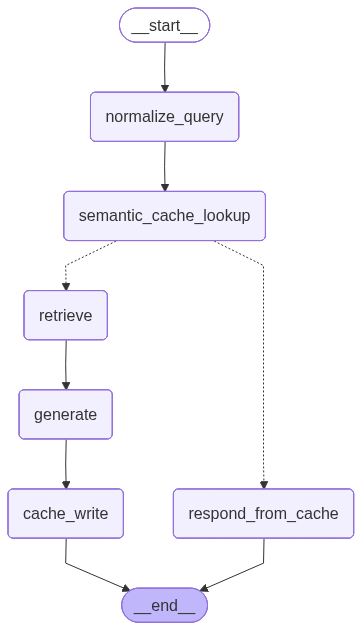

In [20]:
# ============== GRAPH WIRING ==============
graph = StateGraph(RAGState)

graph.add_node("normalize_query", normalize_query)
graph.add_node("semantic_cache_lookup", semantic_cache_lookup)
graph.add_node("respond_from_cache", respond_from_cache)
graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)
graph.add_node("cache_write", cache_write)

graph.set_entry_point("normalize_query")
graph.add_edge("normalize_query", "semantic_cache_lookup")

def _branch(state: RAGState) -> str:
    return "respond_from_cache" if state.get("cache_hit") else "retrieve"

graph.add_conditional_edges(
    "semantic_cache_lookup",
    _branch,
    {
        "respond_from_cache": "respond_from_cache",
        "retrieve": "retrieve"
    }
)

graph.add_edge("respond_from_cache", END)
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", "cache_write")
graph.add_edge("cache_write", END)

memory = MemorySaver()
app = graph.compile(checkpointer=memory)
app

In [21]:
# ================= DEMO ===================
if __name__ == "__main__":
    thread_cfg = {"configurable": {"thread_id": "demo-user-1"}}

    q1 = "What is LangGraph ?"
    out1 = app.invoke({"question": q1, "context_docs": [], "citations": []}, thread_cfg)
    print("Answer:", out1["answer"])
    print("Citations:", out1.get("citations"))
    print("Cache hit?:", out1.get("cache_hit"))

Answer: LangGraph is a framework for building stateful LLM pipelines as graph‑structured workflows. It lets you compose the various steps of a language‑model application into nodes and edges, and even supports features such as node‑level caching of outputs keyed by inputs [doc‑2][doc‑1].
Citations: ['[doc-1]', '[doc-2]', '[doc-3]', '[doc-4]']
Cache hit?: False


In [22]:
q1 = "Explain about LangGraph ?"
out1 = app.invoke({"question": q1, "context_docs": [], "citations": []}, thread_cfg)
print("Answer:", out1["answer"])
print("Citations:", out1.get("citations"))
print("Cache hit?:", out1.get("cache_hit"))

Answer: LangGraph is a framework for building stateful LLM pipelines as graph‑structured workflows. It lets you compose the various steps of a language‑model application into nodes and edges, and even supports features such as node‑level caching of outputs keyed by inputs [doc‑2][doc‑1].
Citations: ['(cache)']
Cache hit?: True


In [23]:
q1 = "Explain about LangGraph agents ?"
out1 = app.invoke({"question": q1, "context_docs": [], "citations": []}, thread_cfg)
print("Answer:", out1["answer"])
print("Citations:", out1.get("citations"))
print("Cache hit?:", out1.get("cache_hit"))

Answer: LangGraph agents are building blocks for **stateful LLM workflows** that are assembled as directed graphs. Each agent (or “node”) can hold its own mutable state, run a language model, and pass results to downstream nodes, enabling complex, multi‑step reasoning or tool‑use patterns.  

Key features of LangGraph agents include:

* **Graph‑based composition** – you define a workflow by connecting agents as nodes, letting the system orchestrate the flow of data and control across them [doc‑2].  
* **State management** – each node maintains its own state (e.g., conversation history, tool outputs), which persists across calls and can be inspected or updated during execution.  
* **Node caching** – outputs of a node can be memoized and reused for identical inputs for a configurable time‑to‑live, reducing redundant LLM calls [doc‑1].  

Together, these capabilities let developers create modular, reusable agents that can be combined into sophisticated retrieval‑augmented generation (RAG

In [ ]:
q1 = "Explain about agents in Langgraph ?"
out1 = app.invoke({"question": q1, "context_docs": [], "citations": []}, thread_cfg)
print("Answer:", out1["answer"])
print("Citations:", out1.get("citations"))
print("Cache hit?:", out1.get("cache_hit"))

Answer: LangGraph agents are building blocks for **stateful LLM workflows** that are assembled as directed graphs. Each agent (or “node”) can hold its own mutable state, run a language model, and pass results to downstream nodes, enabling complex, multi‑step reasoning or tool‑use patterns.  

Key features of LangGraph agents include:

* **Graph‑based composition** – you define a workflow by connecting agents as nodes, letting the system orchestrate the flow of data and control across them [doc‑2].  
* **State management** – each node maintains its own state (e.g., conversation history, tool outputs), which persists across calls and can be inspected or updated during execution.  
* **Node caching** – outputs of a node can be memoized and reused for identical inputs for a configurable time‑to‑live, reducing redundant LLM calls [doc‑1].  

Together, these capabilities let developers create modular, reusable agents that can be combined into sophisticated retrieval‑augmented generation (RAG

: 